In [1]:
import pandas as pd
import numpy as np

# Load diabetes dataset
df = pd.read_csv("../dataset/diabetes.csv")

df.head() 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print("Dataset Shape:", df.shape)

Dataset Shape: (768, 9)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [8]:
data = df.copy()

In [9]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

(data[zero_columns] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [10]:
for column in zero_columns:
    data[column] = data[column].fillna(data[column].median())

In [11]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [16]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [18]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.4888 - loss: 0.7156 - precision: 0.3746 - recall: 0.7118 - val_accuracy: 0.7236 - val_loss: 0.6590 - val_precision: 0.6667 - val_recall: 0.4545
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6660 - loss: 0.6561 - precision: 0.5214 - recall: 0.4294 - val_accuracy: 0.7398 - val_loss: 0.6082 - val_precision: 0.7727 - val_recall: 0.3864
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7230 - loss: 0.6043 - precision: 0.6977 - recall: 0.3529 - val_accuracy: 0.7480 - val_loss: 0.5622 - val_precision: 0.7600 - val_recall: 0.4318
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7413 - loss: 0.5610 - precision: 0.6748 - recall: 0.4882 - val_accuracy: 0.7724 - val_loss: 0.5236 - val_precision: 0.7667 - val_recall: 0.5227
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7637 - loss: 0.5352 - precision: 0.7368 - recall: 0.4941 - val_accuracy: 0.7724 - val_loss: 0.

In [19]:
test_results = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_results[0])
print("Test Accuracy:", test_results[1])
print("Test Precision:", test_results[2])
print("Test Recall:", test_results[3])

Test Loss: 0.5386256575584412
Test Accuracy: 0.7402597665786743
Test Precision: 0.6666666865348816
Test Recall: 0.5185185074806213


[[86 14]
 [26 28]]


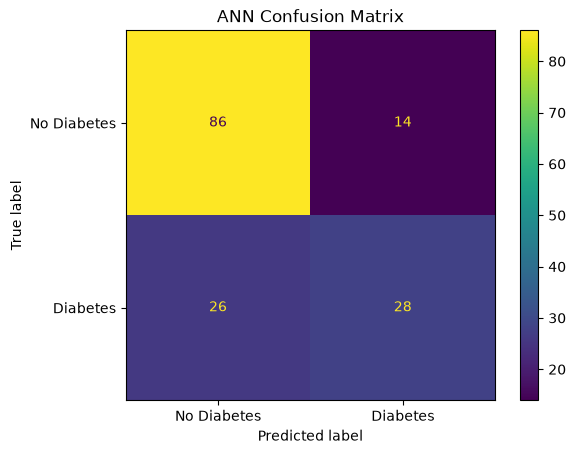

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predicted probabilities
y_pred_prob = model.predict(X_test_scaled, verbose=0)

# Convert probabilities to 0/1
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.8127777777777777


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int).flatten()

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Precision: 0.557 | Recall: 0.815 | F1: 0.662
Threshold: 0.35 | Precision: 0.615 | Recall: 0.741 | F1: 0.672
Threshold: 0.40 | Precision: 0.643 | Recall: 0.667 | F1: 0.655
Threshold: 0.45 | Precision: 0.667 | Recall: 0.593 | F1: 0.627
Threshold: 0.50 | Precision: 0.667 | Recall: 0.519 | F1: 0.583
Threshold: 0.55 | Precision: 0.632 | Recall: 0.444 | F1: 0.522
Threshold: 0.60 | Precision: 0.657 | Recall: 0.426 | F1: 0.517


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, lr_prob))

Logistic Regression
Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56
ROC-AUC  : 0.8229629629629629


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest
Accuracy : 0.7207792207792207
Precision: 0.5873015873015873
Recall   : 0.6851851851851852
F1 Score : 0.6324786324786325
ROC-AUC  : 0.8255555555555556


In [25]:
ann_prob = model.predict(X_test_scaled, verbose=0).flatten()
ann_pred = (ann_prob >= 0.5).astype(int)

print("ANN")
print("Accuracy :", accuracy_score(y_test, ann_pred))
print("Precision:", precision_score(y_test, ann_pred))
print("Recall   :", recall_score(y_test, ann_pred))
print("F1 Score :", f1_score(y_test, ann_pred))
print("ROC-AUC  :", roc_auc_score(y_test, ann_prob))

ANN
Accuracy : 0.7402597402597403
Precision: 0.6666666666666666
Recall   : 0.5185185185185185
F1 Score : 0.5833333333333334
ROC-AUC  : 0.8127777777777777


In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "ANN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ann_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, ann_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, ann_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, ann_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, ann_prob)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.714,0.609,0.519,0.560,0.823
1,Random Forest,0.721,0.587,0.685,0.632,0.826
2,ANN,0.740,0.667,0.519,0.583,0.813


In [27]:
import os

os.makedirs("../model", exist_ok=True)

model.save("../model/diabetes_ann.keras")

In [28]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

In [29]:
import os

print(os.listdir("../model"))

['diabetes_ann.keras', 'scaler.pkl']
